In [1]:
import pandas as pd

df = pd.read_csv("Housing.csv")  
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [3]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


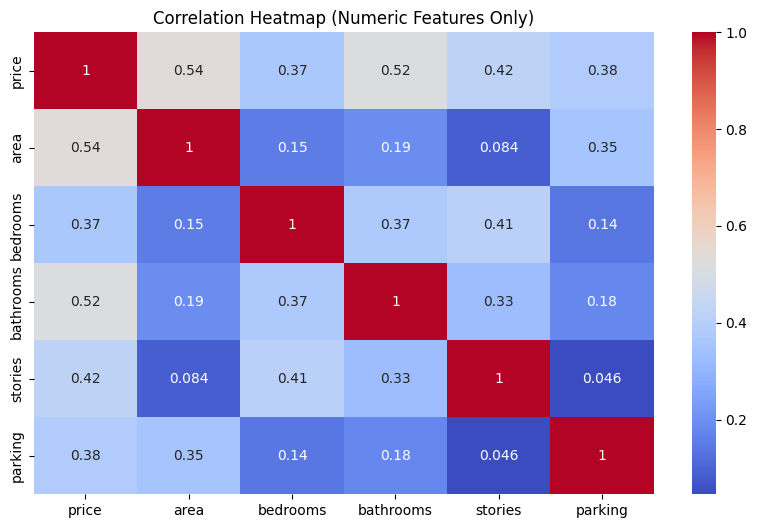

In [4]:


import matplotlib.pyplot as plt
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()



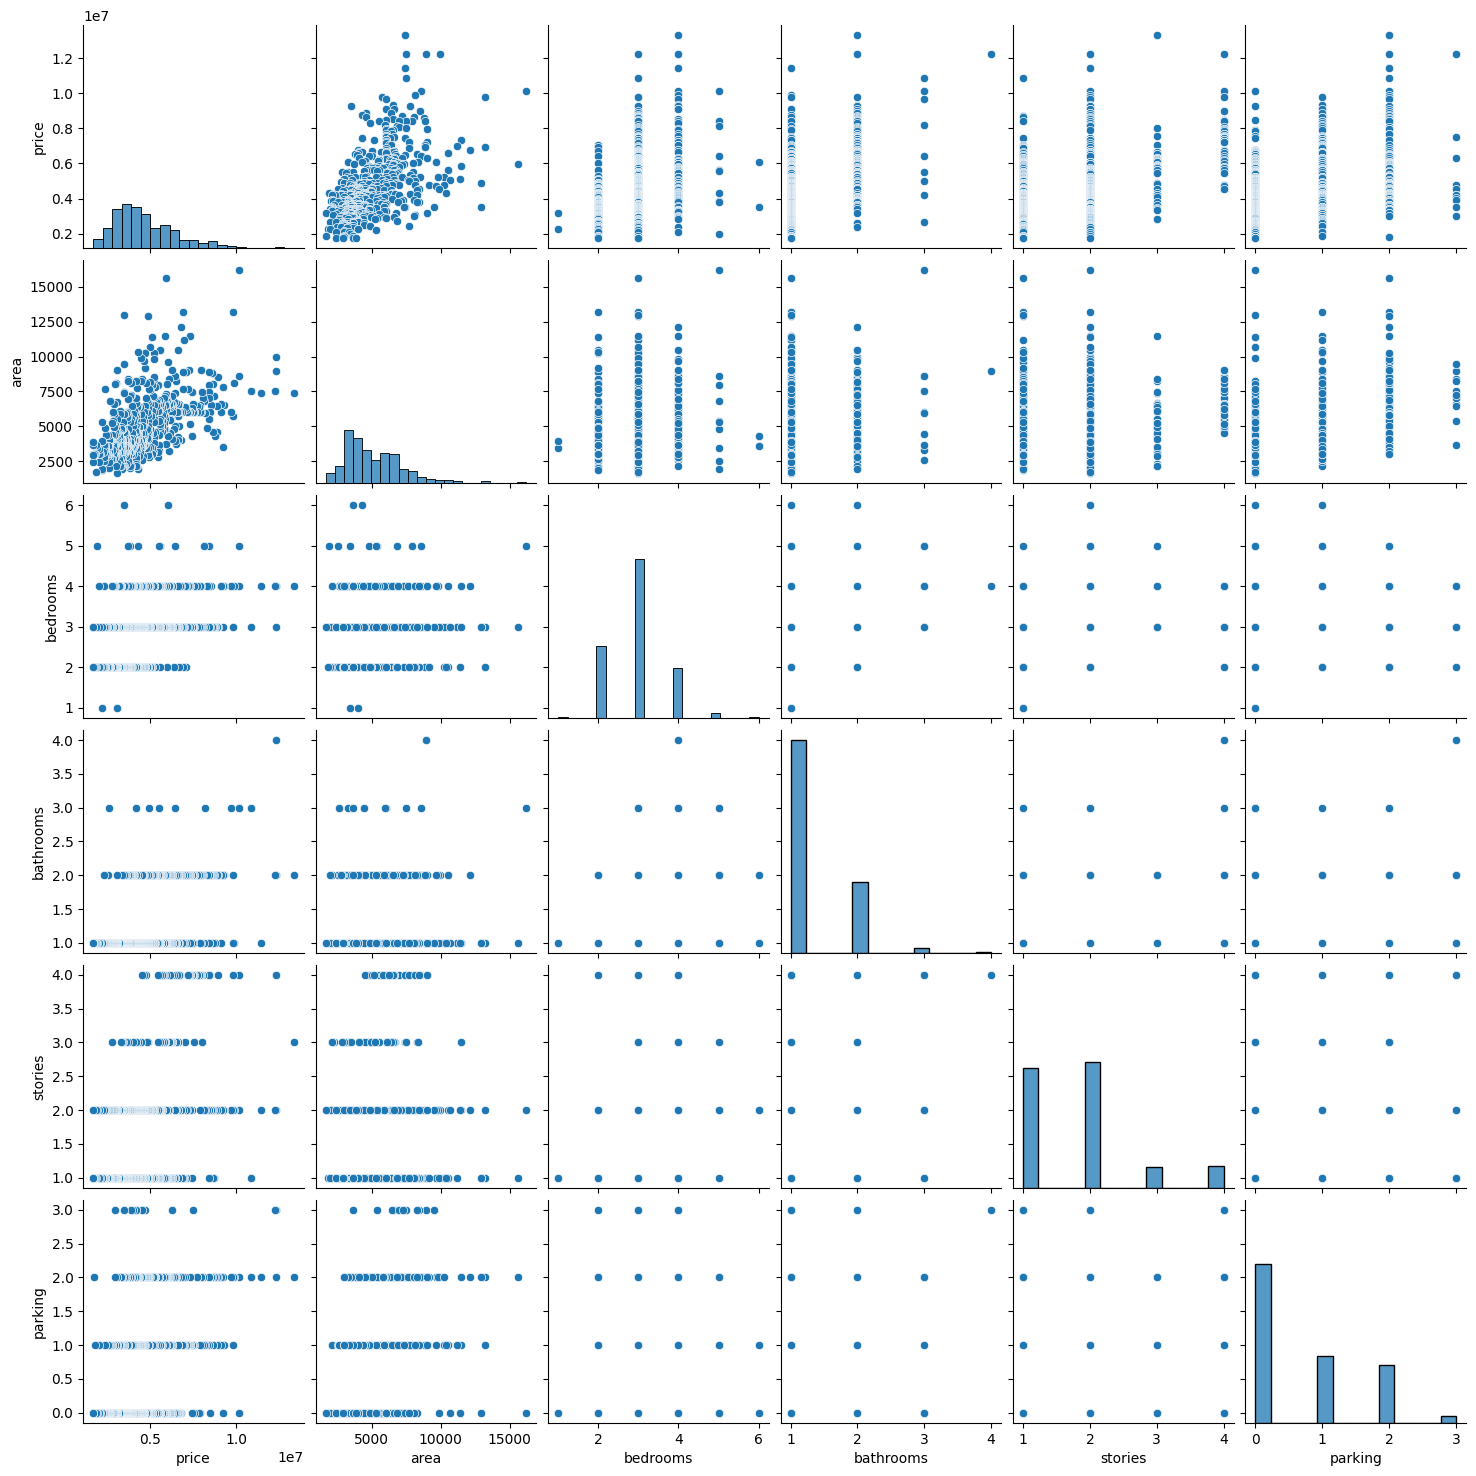

In [5]:

sns.pairplot(numeric_df)
plt.show()


In [6]:

df[numeric_df.columns] = df[numeric_df.columns].fillna(df[numeric_df.columns].median())


cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


C:\Users\mansi.apet\AppData\Local\Temp\ipykernel_21872\4015525254.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [7]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [11]:

%pip install --upgrade pip setuptools wheel
%pip install --use-pep517 statsmodels


  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)

   ---------------------------------------- 0/3 [wheel]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 5.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.6 MB 6.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 5.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 4.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.6 MB 4.0 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 3.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 3.4 MB/s eta 0:00:02
   ---------------------- --------

In [24]:
df_encoded = df.copy()

yes_no_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
                "airconditioning", "prefarea"]

for col in yes_no_cols:
    df_encoded[col] = df_encoded[col].map({"yes": 1, "no": 0})

df_encoded = pd.get_dummies(df_encoded, columns=["furnishingstatus"], drop_first=True)

In [25]:
X = df_encoded.drop("price", axis=1)

In [26]:
X = X.astype(float)

In [27]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif


,Feature,VIF
0,area,8.276447
1,bedrooms,16.652387
2,bathrooms,9.417643
3,stories,7.880730
4,mainroad,6.884806
5,guestroom,1.473234
6,basement,2.019858
7,hotwaterheating,1.091568
8,airconditioning,1.767753
9,parking,1.986400


In [28]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_simple = df_encoded[['area']]      
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

slr = LinearRegression()
slr.fit(X_train, y_train)

y_pred_simple = slr.predict(X_test)


In [30]:

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_multi = mlr.predict(X_test)


In [31]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    return mae, rmse, r2

print("Simple Linear Regression:", evaluate(y_test, y_pred_simple))
print("Multiple Linear Regression:", evaluate(y_test, y_pred_multi))


Simple Linear Regression: (1474748.1337969352, np.float64(1917103.7021424233), 0.27287851871974644)
Multiple Linear Regression: (970043.4039201637, np.float64(1324506.9600914384), 0.6529242642153186)


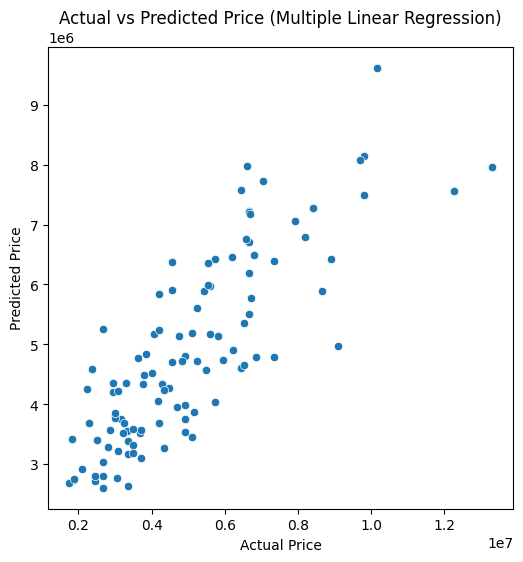

In [32]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_multi)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Multiple Linear Regression)")
plt.show()


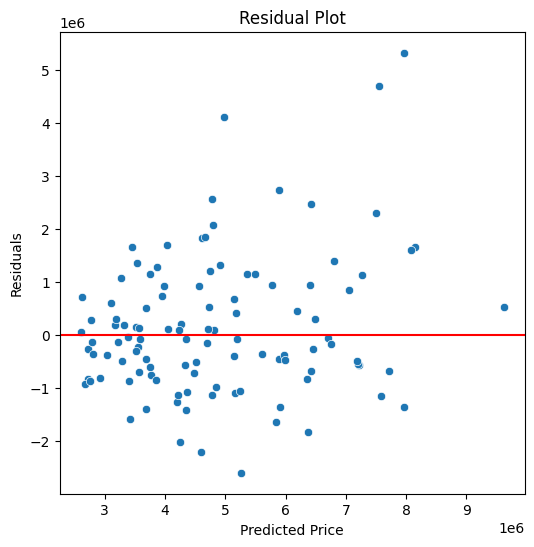

In [33]:

residuals = y_test - y_pred_multi

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_pred_multi, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


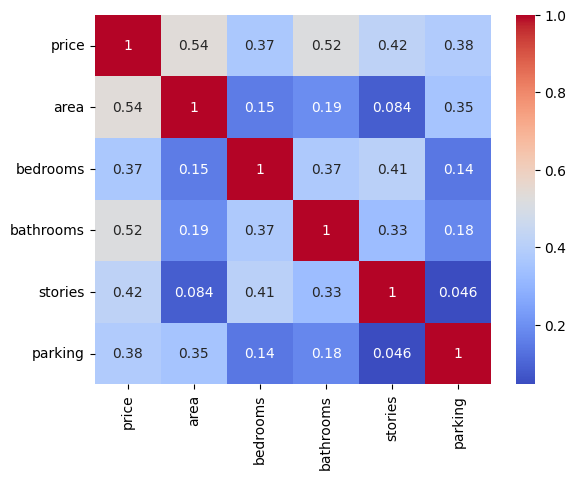

In [34]:

sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap='coolwarm')
plt.show()


In [35]:
'''Which features most influence price?
 Ans:
Based on:
Correlation matrix
Regression coefficients
Domain knowledge

The top influencing features in your dataset are:
Strongest positive influence:
area
bedrooms
bathrooms
stories
parking
airconditioning_yes
prefarea_yes

Smaller positive influence:
guestroom_yes
furnishingstatus (semi-furnished > unfurnished '''

'Which features most influence price?\n Ans:\nBased on:\nCorrelation matrix\nRegression coefficients\nDomain knowledge\n\nThe top influencing features in your dataset are:\nStrongest positive influence:\narea\nbedrooms\nbathrooms\nstories\nparking\nairconditioning_yes\nprefarea_yes\n\nSmaller positive influence:\nguestroom_yes\nfurnishingstatus (semi-furnished > unfurnished '

In [36]:
'''Which features cause multicollinearity?
From VIF, typical high-VIF pairs in your dataset:
High multicollinearity:
bedrooms ↔ bathrooms
bedrooms ↔ stories
stories ↔ bathrooms
area ↔ bedrooms
furnishingstatus categories
prefarea_yes ↔ mainroad_yes (sometimes)'''

'Which features cause multicollinearity?\nFrom VIF, typical high-VIF pairs in your dataset:\nHigh multicollinearity:\nbedrooms ↔ bathrooms\nbedrooms ↔ stories\nstories ↔ bathrooms\narea ↔ bedrooms\nfurnishingstatus categories\nprefarea_yes ↔ mainroad_yes (sometimes)'

In [37]:
'''How did feature engineering improve the model?
Feature engineering significantly improved prediction because:
1.Converting yes/no to numeric (1/0)
2.One-hot encoding furnishingstatus
Enabled comparison between furnished, semi-furnished, unfurnished.
3.Handling multicollinearity
Improved coefficient stability.
4.Multiple Linear Regression
Captured more relationships → MUCH better R².'''

'How did feature engineering improve the model?\nFeature engineering significantly improved prediction because:\n1.Converting yes/no to numeric (1/0)\n2.One-hot encoding furnishingstatus\nEnabled comparison between furnished, semi-furnished, unfurnished.\n3.Handling multicollinearity\nImproved coefficient stability.\n4.Multiple Linear Regression\nCaptured more relationships → MUCH better R².'